# Homework 1: Thuật toán Perceptron Learning
## Môn học: Trí Tuệ Nhân Tạo - EE3063

Nhóm Thực Hiện: [Điền tên thành viên nhóm]
MSSV: [Điền MSSV thành viên nhóm]

Nội dung:

1. Giới thiệu và giải thích thuật toán Perceptron.

2. Xây dựng lớp Perceptron bằng Python.

3. Áp dụng thuật toán cho dữ liệu 2D phân tách tuyến tính và trực quan hóa.

4. Áp dụng thuật toán cho dữ liệu 3D phân tách tuyến tính và trực quan hóa.

In [ ]:
# -*- coding: utf-8 -*-
# Thư viện cần thiết cho việc tạo dữ liệu và trực quan hóa
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Cho đồ thị 3D
from sklearn.datasets import make_classification # Dùng để tạo dữ liệu mẫu



## 1. Giới thiệu

Thuật toán Perceptron, được đề xuất bởi Rosenblatt vào năm 1957 và sau đó được Minsky và Papert phân tích sâu hơn vào năm 1969, là một trong những thuật toán học máy có giám sát sớm nhất và đơn giản nhất cho bài toán phân loại nhị phân (binary classification). Nó là một bộ phân loại tuyến tính, nghĩa là nó cố gắng tìm một siêu phẳng (đường thẳng trong không gian 2D, mặt phẳng trong không gian 3D) để chia tách hai lớp dữ liệu.

## 2. Mô hình Perceptron

Một Perceptron nhận đầu vào là một vector đặc trưng $x = [x_1, x_2, ..., x_n]$ và tính toán một tổng có trọng số của các đặc trưng này.

$z = w_1x_1 + w_2x_2 + ... + w_nx_n + b = w \cdot x + b$

Trong đó:
- $w = [w_1, w_2, ..., w_n]$ là vector trọng số.
- $b$ là giá trị ngưỡng (bias), có thể được xem như $w_0$ nếu ta thêm một đặc trưng $x_0 = 1$ vào vector đầu vào, khi đó $z = w_0x_0 + w_1x_1 + ... + w_nx_n$.

Đầu ra của Perceptron được xác định bởi một hàm kích hoạt dạng bước (step function):

$ \hat{y} = \begin{cases} 1 & \text{if } z \ge 0 \\ 0 & \text{if } z < 0 \end{cases} $

(Trong slide "Perceptron.pdf", trang 3, điều kiện là $w \cdot x \ge 0$ cho lớp 1 và $w \cdot x < 0$ cho lớp 0, với $x$ đã bao gồm $x_0=1$ và $w_0 = -\theta$).

## 3. Thuật toán Học (Perceptron Learning Algorithm)

Mục tiêu của thuật toán là tìm ra vector trọng số $w$ sao cho Perceptron có thể phân loại đúng tất cả các điểm dữ liệu huấn luyện (nếu dữ liệu là phân tách tuyến tính).

Các bước thực hiện (dựa trên slide "Perceptron.pdf", trang 6):
1. Khởi tạo vector trọng số $w$ một cách ngẫu nhiên hoặc bằng zero.
2. Lặp qua tập dữ liệu huấn luyện nhiều lần (epochs) hoặc cho đến khi không còn điểm nào bị phân loại sai:
   a. Với mỗi điểm dữ liệu $(x^{(i)}, y^{(i)})$ trong tập huấn luyện:
      i. Tính toán đầu ra dự đoán $\hat{y}^{(i)}$ sử dụng vector trọng số hiện tại $w$.
      ii. Nếu dự đoán sai ($\hat{y}^{(i)} \neq y^{(i)}$):
          - Nếu $y^{(i)} = 1$ và $\hat{y}^{(i)} = 0$ (tức là $w \cdot x^{(i)} < 0$): Cập nhật $w \leftarrow w + x^{(i)}$.
          - Nếu $y^{(i)} = 0$ và $\hat{y}^{(i)} = 1$ (tức là $w \cdot x^{(i)} \ge 0$): Cập nhật $w \leftarrow w - x^{(i)}$.

Một cách viết tổng quát hơn cho quy tắc cập nhật (với learning rate $\eta$ và nhãn là +1/-1):
$w \leftarrow w + \eta(y^{(i)} - \hat{y}^{(i)})x^{(i)}$
Tuy nhiên, slide của thầy sử dụng quy tắc cập nhật đơn giản hơn với nhãn 0/1 và không có learning rate tường minh (có thể coi $\eta=1$). Chúng ta sẽ bám sát slide.

## 4. Điều kiện hội tụ

Thuật toán Perceptron được đảm bảo sẽ hội tụ (tìm được một siêu phẳng phân tách) nếu dữ liệu huấn luyện là **phân tách tuyến tính** (linearly separable). Nếu dữ liệu không phân tách tuyến tính, thuật toán sẽ không hội tụ và có thể lặp vô hạn.

Lớp Perceptron nhóm xây dựng

In [4]:
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        """
        Khởi tạo Perceptron.
        Args:
            learning_rate (float): Tốc độ học (trong slide không đề cập tường minh, 
                                     nhưng quy tắc w = w + x có thể coi là lr=1 khi x được chuẩn hóa
                                     hoặc khi nhãn là +1/-1 và dự đoán sai.
                                     Ở đây ta sẽ dùng quy tắc cập nhật theo slide trang 6).
            n_iters (int): Số lần lặp (epochs) tối đa qua tập dữ liệu.
        """
        self.lr = learning_rate # Sẽ không dùng trực tiếp nếu theo slide
        self.n_iters = n_iters
        self.weights = None
        self.bias = None # Hoặc có thể gộp bias vào weights bằng cách thêm x0=1

    def fit(self, X, y):
        """
        Huấn luyện mô hình Perceptron.
        Args:
            X (np.array): Ma trận đặc trưng huấn luyện, shape (n_samples, n_features).
            y (np.array): Vector nhãn huấn luyện (0 hoặc 1), shape (n_samples,).
        """
        n_samples, n_features = X.shape

        # Khởi tạo trọng số và bias
        # Trọng số được khởi tạo bằng zero hoặc giá trị ngẫu nhiên nhỏ.
        # Bias có thể được xem là w0, và X được thêm một cột x0=1.
        # Hoặc có thể dùng một biến bias riêng.
        # Theo slide, x đã bao gồm x0=1, nên self.weights sẽ có n_features + 1 phần tử.
        self.weights = np.zeros(n_features + 1) # w0, w1, ..., wn

        # Thêm cột x0 = 1 vào X để tính toán với bias w0
        X_b = np.concatenate([np.ones((n_samples, 1)), X], axis=1)

        for _ in range(self.n_iters):
            misclassified_count = 0
            for idx, x_i in enumerate(X_b):
                # Tính linear output: z = w · x
                linear_output = np.dot(x_i, self.weights)
                
                # Dự đoán lớp sử dụng hàm step
                y_predicted = 1 if linear_output >= 0 else 0
                
                # Cập nhật trọng số nếu dự đoán sai
                # (Theo slide "Perceptron.pdf", trang 6)
                update_needed = False
                if y[idx] == 1 and y_predicted == 0: # x_i thuộc lớp P (target=1), dự đoán sai là 0
                    self.weights += x_i # w = w + x
                    update_needed = True
                elif y[idx] == 0 and y_predicted == 1: # x_i thuộc lớp N (target=0), dự đoán sai là 1
                    self.weights -= x_i # w = w - x
                    update_needed = True
                
                if update_needed:
                    misclassified_count += 1
            
            # Điều kiện dừng: nếu không còn điểm nào bị phân loại sai trong một epoch
            if misclassified_count == 0:
                print(f"Hội tụ sau {_ + 1} epochs.")
                break
        
        if misclassified_count != 0 and _ == self.n_iters - 1:
            print(f"Không hội tụ hoàn toàn sau {self.n_iters} epochs. Số điểm phân loại sai cuối cùng: {misclassified_count}")


    def predict(self, X):
        """
        Dự đoán nhãn cho dữ liệu mới.
        Args:
            X (np.array): Ma trận đặc trưng của dữ liệu mới.
        Returns:
            np.array: Vector các nhãn dự đoán.
        """
        n_samples = X.shape[0]
        X_b = np.concatenate([np.ones((n_samples, 1)), X], axis=1)
        linear_output = np.dot(X_b, self.weights)
        y_predicted = np.where(linear_output >= 0, 1, 0)
        return y_predicted

## 5. Áp dụng Perceptron cho dữ liệu 2D

Chúng ta sẽ tạo một tập dữ liệu 2D gồm hai lớp có thể phân tách tuyến tính và huấn luyện mô hình Perceptron trên đó. Sau đó, trực quan hóa các điểm dữ liệu và đường phân cách tìm được.


Tạo dữ liệu 2D phân tách tuyến tính

Hội tụ sau 2 epochs.


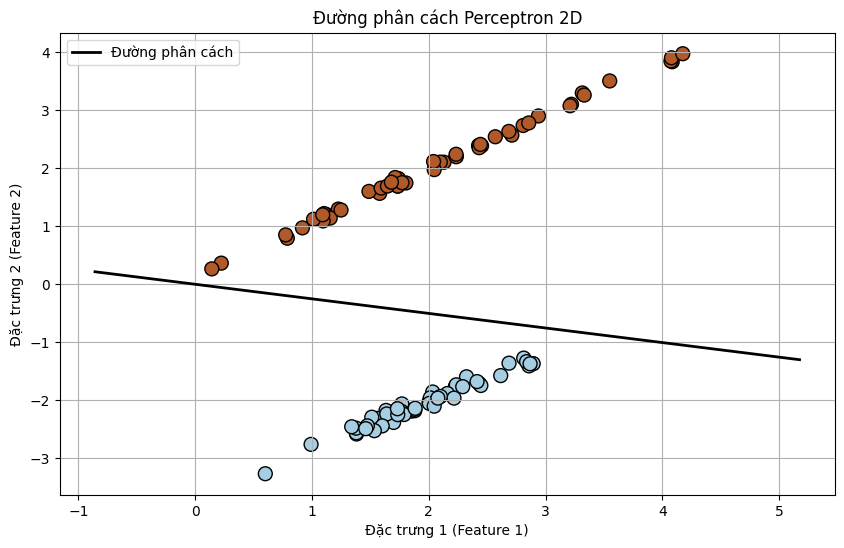

In [5]:
X_2d, y_2d = make_classification(n_samples=100, n_features=2, n_redundant=0, 
                               n_informative=2, random_state=42, 
                               n_clusters_per_class=1, class_sep=2.0)

# Đảm bảo nhãn là 0 và 1
y_2d = np.where(y_2d == -1, 0, y_2d)


# Huấn luyện Perceptron
perceptron_2d = Perceptron(n_iters=100)
perceptron_2d.fit(X_2d, y_2d)

# Trực quan hóa kết quả 2D
def plot_decision_boundary_2d(X, y, model, title="Đường phân cách Perceptron 2D"):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, s=100, edgecolor='k', cmap=plt.cm.Paired)

    # Lấy trọng số w1, w2 và bias w0
    w0 = model.weights[0]
    w1 = model.weights[1]
    w2 = model.weights[2]

    # Đường phân cách: w0 + w1*x1 + w2*x2 = 0
    # => x2 = (-w0 - w1*x1) / w2
    
    # Tạo các điểm x1 để vẽ đường thẳng
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_plot = np.linspace(x1_min, x1_max, 100)
    
    if w2 != 0: # Tránh chia cho 0 nếu đường thẳng đứng
        x2_plot = (-w0 - w1 * x1_plot) / w2
        plt.plot(x1_plot, x2_plot, "k-", linewidth=2, label="Đường phân cách")
        
        # Vẽ lề (không phải là mục tiêu chính của Perceptron nhưng để minh họa)
        # margin_val = 1 / np.sqrt(w1**2 + w2**2) # Chỉ đúng nếu chuẩn hóa
        # plt.plot(x1_plot, x2_plot + margin_val, "k--", linewidth=1)
        # plt.plot(x1_plot, x2_plot - margin_val, "k--", linewidth=1)

    elif w1 != 0: # Nếu đường nằm ngang (w2=0)
        # w0 + w1*x1 = 0 => x1 = -w0/w1 (đường thẳng đứng)
        plt.axvline(x=-w0/w1, color='k', linestyle='-', linewidth=2, label="Đường phân cách")
    else:
        print("Không thể vẽ đường phân cách (trọng số w1, w2 đều bằng 0).")


    plt.xlabel("Đặc trưng 1 (Feature 1)")
    plt.ylabel("Đặc trưng 2 (Feature 2)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary_2d(X_2d, y_2d, perceptron_2d)

## 6. Áp dụng Perceptron cho dữ liệu 3D

Tương tự, chúng ta sẽ tạo một tập dữ liệu 3D gồm hai lớp có thể phân tách tuyến tính.
Mô hình Perceptron sẽ cố gắng tìm một mặt phẳng để phân tách hai lớp này.

Hội tụ sau 2 epochs.


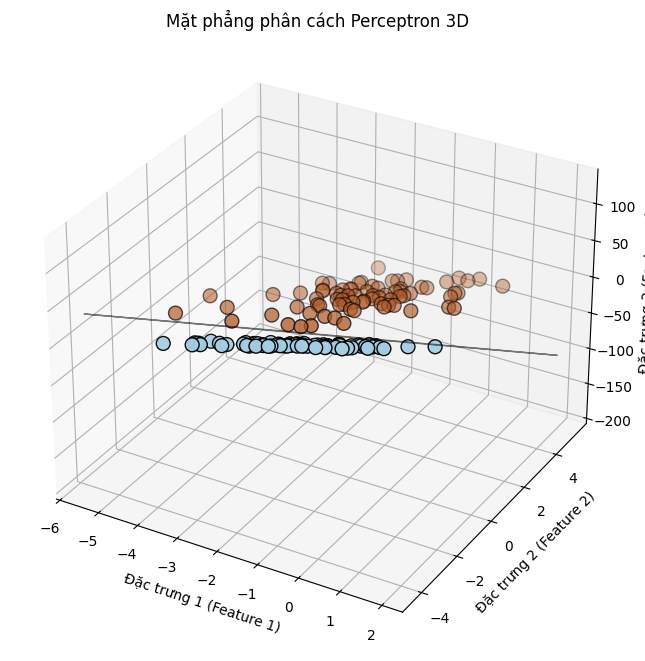

In [6]:
# Tạo dữ liệu 3D phân tách tuyến tính
X_3d, y_3d = make_classification(n_samples=150, n_features=3, n_redundant=0,
                               n_informative=3, random_state=22,
                               n_clusters_per_class=1, class_sep=1.5)
y_3d = np.where(y_3d == -1, 0, y_3d)


# Huấn luyện Perceptron
perceptron_3d = Perceptron(n_iters=100)
perceptron_3d.fit(X_3d, y_3d)

# Trực quan hóa kết quả 3D
def plot_decision_boundary_3d(X, y, model, title="Mặt phẳng phân cách Perceptron 3D"):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(X[:, 0], X[:, 1], X[:, 2], marker='o', c=y, s=100, edgecolor='k', cmap=plt.cm.Paired)

    # Lấy trọng số w0, w1, w2, w3
    w0 = model.weights[0]
    w1 = model.weights[1]
    w2 = model.weights[2]
    w3 = model.weights[3]

    # Mặt phẳng phân cách: w0 + w1*x1 + w2*x2 + w3*x3 = 0
    # => x3 = (-w0 - w1*x1 - w2*x2) / w3
    
    # Tạo lưới điểm cho x1, x2 để vẽ mặt phẳng
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 10), 
                           np.linspace(x2_min, x2_max, 10))
    
    if w3 != 0: # Tránh chia cho 0
        xx3 = (-w0 - w1 * xx1 - w2 * xx2) / w3
        ax.plot_surface(xx1, xx2, xx3, alpha=0.5, rstride=100, cstride=100, color='cyan', edgecolor='k')
    elif w2 != 0: # Nếu mặt phẳng song song với trục x3 (w3=0)
        # w0 + w1*x1 + w2*x2 = 0 => x2 = (-w0 - w1*x1)/w2
        xx3_const = np.zeros_like(xx1) # Vẽ mặt phẳng tại một giá trị x3 cố định (ví dụ z=0)
        xx2_plane = (-w0 - w1*xx1)/w2
        # Cần điều chỉnh cách vẽ cho trường hợp này, ví dụ vẽ các đường contour
        print("Mặt phẳng song song với trục x3, cần cách trực quan hóa khác.")
    # Các trường hợp khác (w1!=0 hoặc tất cả w1,w2,w3=0) có thể phức tạp hơn để vẽ
    else:
        print("Không thể vẽ mặt phẳng phân cách (trọng số w1, w2, w3 gần bằng 0).")


    ax.set_xlabel("Đặc trưng 1 (Feature 1)")
    ax.set_ylabel("Đặc trưng 2 (Feature 2)")
    ax.set_zlabel("Đặc trưng 3 (Feature 3)")
    ax.set_title(title)
    # plt.legend() # Khó đặt legend cho scatter 3D và surface
    plt.show()

plot_decision_boundary_3d(X_3d, y_3d, perceptron_3d)

## 7. Nhận xét

- Thuật toán Perceptron đã được xây dựng thành công từ đầu bằng Python.
- Mô hình có khả năng tìm ra đường phân cách tuyến tính cho dữ liệu 2D và mặt phẳng phân cách cho dữ liệu 3D khi dữ liệu là phân tách tuyến tính.
- Quá trình huấn luyện dựa trên việc cập nhật trọng số mỗi khi có một điểm bị phân loại sai, theo đúng quy tắc trong slide bài giảng.
- Điều kiện hội tụ là khi không còn điểm nào bị phân loại sai, hoặc đạt đến số vòng lặp tối đa.
- Trong các ví dụ trên, dữ liệu được tạo ra là phân tách tuyến tính, nên thuật toán Perceptron có thể hội tụ và tìm được một siêu phẳng phân cách.

### Hạn chế của Perceptron:
- Chỉ hoạt động tốt với dữ liệu phân tách tuyến tính. Nếu dữ liệu không phân tách tuyến tính, thuật toán sẽ không hội tụ.
- Có thể có nhiều siêu phẳng phân cách khác nhau, Perceptron không đảm bảo tìm ra siêu phẳng "tốt nhất" (ví dụ, siêu phẳng có lề lớn nhất như SVM).
- Nhạy cảm với việc khởi tạo trọng số và thứ tự duyệt dữ liệu (trong phiên bản online).
